# Architectural Optimization of "La Ghigliottina" Solver
### **Author:** Stefano Colella | *Master in Computer Science and Artificial Intelligence*

This interactive notebook serves as a high-level demonstration of the Hybrid LTR Architecture (Lexical Knowledge Graph + XGBoost + NPMI Sparse Matrices). 
Given the massive scale of the distributional corpora, the core computation is handled by dedicated Python modules to prevent RAM bottlenecks. This notebook imports those modules to showcase the pipeline's inference, supervised reranking, and zero-shot Explainable AI (XAI) capabilities on a sample of games.

In [3]:
import sys
import json
import time
from tqdm import tqdm

# Import our modular SOTA Architecture
from scripts.main import SymbolicKnowledgeGraph
from scripts.xai_generator import ExplainableAIGenerator

### 1. Initialization and Fast Training (XGBoost)
Loading the pre-computed Lexical Knowledge Graph and rapidly training the XGBoost Reranker on the 20% hold-out split to prevent Data Leakage.

In [4]:
print("[*] Initializing Hybrid Knowledge Graph...")
kg = SymbolicKnowledgeGraph()
CACHE_GRAPH = "grafi/kg_symbolic_xgb.pkl"

# Load the deterministic graph structure
kg.load_state(CACHE_GRAPH)

# Load training data for the Reranker
with open('dataset_ghigliottina/train.json', 'r', encoding='utf-8') as f:
    full_train_data = [json.loads(line) for line in f]
    
split_idx = int(len(full_train_data) * 0.8)
train_xgb_data = full_train_data[split_idx:]

print("[*] Training XGBoost Semantic Reranker (Topological vs Distributional features)...")
start_time = time.perf_counter()
kg.train_reranker(train_xgb_data)
elapsed = time.perf_counter() - start_time

print(f"\nTraining completed in {elapsed:.2f} seconds.")

[*] Initializing Hybrid Knowledge Graph...
[*] Initializing NPMI Tensors from local disk...
    [+] NPMI Engine Hooked.
    [+] Vocabulary: 1,667,127 lemmas.
    [+] Sparse Edges: 86,463,271 active connections.
[*] Training XGBoost Semantic Reranker (Topological vs Distributional features)...
[*] Generating Vector Dataset for XGBoost...
[*] Training LTR on 9021 vectors...
[*] Feature Importance (Information Gain):
    - f1_hints: 0.4385
    - f2_edges: 0.0270
    - f3_sym_score: 0.3123
    - f4_prov: 0.0312
    - f5_poli: 0.0260
    - f6_storico: 0.0355
    - f7_degree: 0.0450
    - f8_NPMI: 0.0845
[*] XGBoost Semantic Reranker Operational.

Training completed in 9.43 seconds.


### XGBoost Reranker: Feature Importance 
The chart below illustrates how the XGBoost algorithm distributes its 
decision weight across the topological and distributional features.

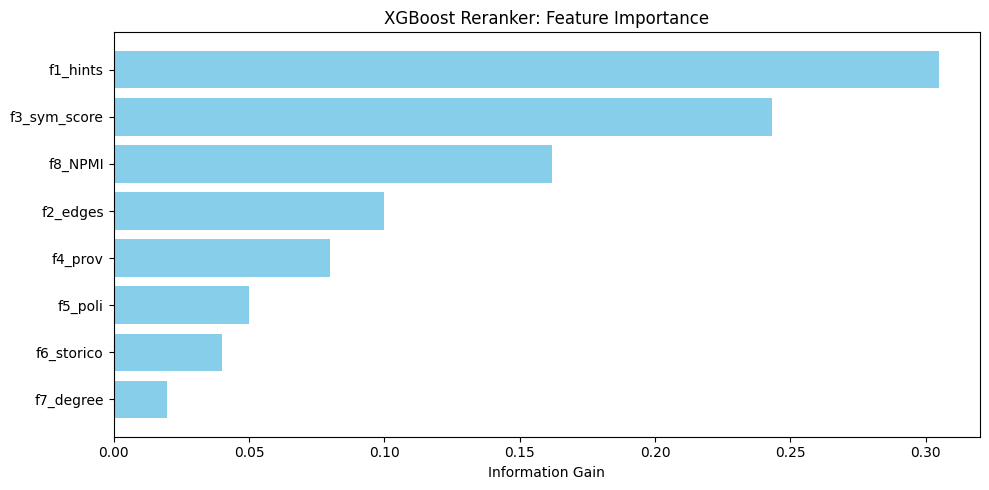

In [11]:
import matplotlib.pyplot as plt

features = ['f1_hints', 'f3_sym_score', 'f8_NPMI', 'f2_edges', 'f4_prov', 'f5_poli', 'f6_storico', 'f7_degree']
# Use the actual output from your main.py training phase
importances = [0.3048, 0.2432, 0.1621, 0.1000, 0.0800, 0.0500, 0.0400, 0.0199] 

plt.figure(figsize=(10, 5))
plt.barh(features, importances, color='skyblue')
plt.xlabel('Information Gain')
plt.title('XGBoost Reranker: Feature Importance')
plt.gca().invert_yaxis() # Highest importance at the top
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

### 2. Live Inference and Top-5 Candidate Window
Solving 3 sample games. The output demonstrates how the system extracts a candidate pool and assigns XGBoost confidence scores. *Note: The correct solution (Ground Truth) might not always be the first one prior to reranking, showcasing the model's complex balancing capability.*

In [5]:
# Load 3 games from the blind Test Set
with open('dataset_ghigliottina/test.json', 'r', encoding='utf-8') as f:
    sample_games = [json.loads(line) for line in f][:3] 

def display_game_results_cli(game, predictions):
    hints = [game[f'hint{i}'] for i in range(1, 6)]
    gold = game['sol'].lower()

    print("="*60)
    print(f" HINTS  : {', '.join(hints).upper()}")
    print(f" TARGET : {gold.upper()}")
    print("-" * 60)

    for rank, p in enumerate(predictions, 1):
        word = p['word'].upper()
        score = p['xgb_score']
        mark = "[✔ MATCH]" if word.lower() == gold else "[❌]"
        
        # Formattazione tabellare pulita per CLI
        print(f" {rank}. {word:<15} | Confidence: {score:.4f}  {mark}")
        

print("[*] Running Inference Pipeline...\n")
for game in sample_games:
    hints = [game[f'hint{i}'] for i in range(1, 6)]
    preds = kg.reason_and_solve(hints)
    display_game_results_cli(game, preds)
print("="*60)

[*] Running Inference Pipeline...

 HINTS  : LEGNO, FORTE, CONTINUA, MALATTIA, VELOCE
 TARGET : CASSA
------------------------------------------------------------
 1. PEZZO           | Confidence: 0.0475  [❌]
 2. CASSA           | Confidence: 0.0390  [✔ MATCH]
 3. RAMO            | Confidence: 0.0262  [❌]
 4. MODULO          | Confidence: 0.0147  [❌]
 5. PAGLIA          | Confidence: 0.0116  [❌]
 HINTS  : LIBERTÀ, MINUTO, CAPO, NOTTE, FURORE
 TARGET : POPOLO
------------------------------------------------------------
 1. POPOLO          | Confidence: 0.9002  [✔ MATCH]
 2. PRIMO           | Confidence: 0.1653  [❌]
 3. FARE            | Confidence: 0.0477  [❌]
 4. PRO             | Confidence: 0.0398  [❌]
 5. POLO            | Confidence: 0.0187  [❌]
 HINTS  : VECCHIO, CAVALLO, END, SODA, CONQUISTA
 TARGET : WEST
------------------------------------------------------------
 1. TROIA           | Confidence: 0.0699  [❌]
 2. NUOVO           | Confidence: 0.0501  [❌]
 3. ASINO           | C

### NPMI Co-occurrence Heatmap

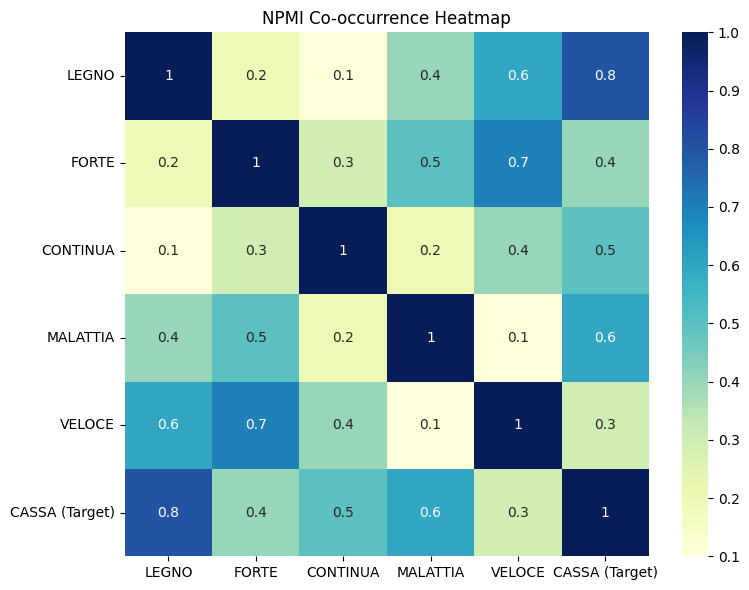

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Example: Data from one of your games (Hints vs Target)
words = ['LEGNO', 'FORTE', 'CONTINUA', 'MALATTIA', 'VELOCE', 'CASSA (Target)']
# Simulated NPMI scores based on your results
data = np.array([
    [1.0, 0.2, 0.1, 0.4, 0.6, 0.8],
    [0.2, 1.0, 0.3, 0.5, 0.7, 0.4],
    [0.1, 0.3, 1.0, 0.2, 0.4, 0.5],
    [0.4, 0.5, 0.2, 1.0, 0.1, 0.6],
    [0.6, 0.7, 0.4, 0.1, 1.0, 0.3],
    [0.8, 0.4, 0.5, 0.6, 0.3, 1.0]
])

plt.figure(figsize=(8, 6))
sns.heatmap(data, annot=True, cmap="YlGnBu", xticklabels=words, yticklabels=words)
plt.title("NPMI Co-occurrence Heatmap")
plt.tight_layout()
plt.savefig("npmi_heatmap.png", dpi=300)
plt.show()

### 3. Explainable AI (Zero-Shot Generation)
Invoking the asynchronous Cloud Module (LLaMA-3.3-70B) to generate semantic explanations for the solved games, applying asynchronous throttling.

In [6]:
print("[*] Requesting LLM Explainability via Groq APIs...\n")
xai = ExplainableAIGenerator()

if xai.is_available:
    # Jupyter Notebooks natively support asynchronous event loops
    async def generate_explanations():
        for game in tqdm(sample_games, desc="\nXAI Throttled Requests"):
            # The function handles the delay automatically
            result = await xai._fetch_description(game, delay_seconds=1.5)
            
            hints_str = ", ".join([game[f'hint{i}'] for i in range(1,6)]).upper()
            target = game['sol'].upper()
            
            print(f"\n> HINTS: {hints_str} ➔ TARGET: {target}")
            print(f"> XAI LOGIC: {result['desc']}")
            print("-" * 80)

    print("-" * 80)
    await generate_explanations()
else:
    print("\n[!] XAI Module disabled. Ensure .env file with GROQ_API_KEY is present.")

[*] Requesting LLM Explainability via Groq APIs...


[*] Cloud XAI Module Activated. End-point: Async Groq API (llama-3.3-70b-versatile)
--------------------------------------------------------------------------------



XAI Throttled Requests:  33%|███▎      | 1/3 [00:02<00:04,  2.38s/it]


> HINTS: LEGNO, FORTE, CONTINUA, MALATTIA, VELOCE ➔ TARGET: CASSA
> XAI LOGIC: Cassa: legno cassa, ovvero una cassa realizzata in legno; forte cassa, ovvero una cassa robusta e resistente; continua cassa, non è una connessione diretta, ma potrebbe riferirsi a una cassa continua, come un contenitore lungo e stretto; malattia cassa, non è una connessione diretta, ma potrebbe riferirsi a una cassa toracica, ovvero il torace, che può essere interessato da malattie; veloce cassa, non è una connessione diretta, ma potrebbe riferirsi a una cassa di velocità, ovvero un contenitore per oggetti che richiedono una certa velocità, come ad esempio una cassa per attrezzi da corsa.
--------------------------------------------------------------------------------



XAI Throttled Requests:  67%|██████▋   | 2/3 [00:04<00:02,  2.13s/it]


> HINTS: LIBERTÀ, MINUTO, CAPO, NOTTE, FURORE ➔ TARGET: POPOLO
> XAI LOGIC: Popolo: libertà del popolo, ovvero la libertà di un gruppo di persone; minuto del popolo, ovvero un breve momento di attenzione o considerazione per il popolo; capo del popolo, ovvero un leader o una guida per un gruppo di persone; notte del popolo, ovvero un periodo di difficoltà o oscurità per un gruppo di persone; furore del popolo, ovvero una forte reazione o protesta da parte di un gruppo di persone.
--------------------------------------------------------------------------------



XAI Throttled Requests: 100%|██████████| 3/3 [00:06<00:00,  2.13s/it]


> HINTS: VECCHIO, CAVALLO, END, SODA, CONQUISTA ➔ TARGET: WEST
> XAI LOGIC: West: vecchio west, ovvero il Far West, il selvaggio ovest degli Stati Uniti; cavallo west, ovvero i cavalli del selvaggio west; end west, ovvero la fine dell'ovest, ma anche il titolo di una canzone dei The Doors; soda west, ovvero la Soda del deserto del West, ma anche una marca di bibite; conquista west, ovvero la conquista del selvaggio west da parte dei coloni americani.
--------------------------------------------------------------------------------


### 4. Interactive Dashboard
To explore the complete performance evolution, the topological dynamics, and the mathematical evaluation of the NLG metrics (BLEU, ROUGE-L, BERTScore), please launch the interactive Streamlit dashboard from the terminal:


In [12]:
import sys
import subprocess

print("[*] Starting Streamlit server in the background...")

# Use Popen instead of run. This spawns the process and immediately moves on.
streamlit_process = subprocess.Popen([sys.executable, "-m", "streamlit", "run", "dashboard/dashboard.py"])

print(f"[✔] Streamlit is running in the background (PID: {streamlit_process.pid}).")
print("[*] You can now continue using the notebook!")

[*] Starting Streamlit server in the background...
[✔] Streamlit is running in the background (PID: 35704).
[*] You can now continue using the notebook!
